In [1]:
import Preprocessing
import pandas as pd
import numpy
league='LaLiga'
dataset_laliga=pd.read_csv('datasets\SP1.csv').iloc[:,:23]
dataset_laliga,team_stats=Preprocessing.preprocess(dataset_laliga)
dataset_laliga,teams_elo=Preprocessing.calculate_team_elo(dataset_laliga,league)
dataset_laliga=dataset_laliga.sort_values('Date')
dataset_laliga=dataset_laliga.drop(columns=['Date','FTAG','FTHG','HTR','HS','AS','Day','Month','HY','AY',
                              'HTHG','HTAG','HST','AST','HF','AF','HC','AC'])
X=dataset_laliga.drop(columns=['FTR']).values
y=dataset_laliga['FTR'].values

<>:5: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
<>:5: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
C:\Users\stepa\AppData\Local\Temp\ipykernel_20752\2519305945.py:5: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
  dataset_laliga=pd.read_csv('datasets\SP1.csv').iloc[:,:23]


In [2]:
team_stats.head(5)

,Date,Team,Scored,Conceded,Shots_made,Shots_Conceded,Shots_ontarget_made,Shots_ontarget_conceded,Corners_made,Corners_conceded,...,Avg_Conceded_Last_5,Wins_Last_5,Losses_Last_5,Draws_Last_5,Avg_Shots_Last_5,Avg_Shots_Conceded_Last_5,Avg_shots_ontarget_Last_5,Avg_shots_ontarget_Conceded_Last_5,Avg_corners_Last_5,Avg_corners_conceded_Last_5
0,2025-08-16,Alaves,2,1,15,7,4,3,10,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2025-08-22,Alaves,0,1,11,16,5,5,2,5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2025-08-30,Alaves,1,1,5,15,2,6,1,6,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2025-09-13,Alaves,1,0,4,12,2,3,6,6,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2025-09-20,Alaves,1,2,8,9,5,3,4,4,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
dataset_laliga.head(10)

,HomeTeam,AwayTeam,FTR,Home_Days_Rest,Away_Days_Rest,Home_Avg_Scored_5,Home_Avg_Conceded_5,Home_Avg_Shots_Last_5,Home_Avg_Shots_Conceded_Last_5,Home_Wins_Last_5,Home_Losses_Last_5,Away_Avg_Scored_5,Away_Avg_Conceded_5,Away_Avg_Shots_Last_5,Away_Avg_Shots_Conceded_Last_5,Away_Wins_Last_5,Away_Losses_Last_5,Home_ELO_Score,Away_ELO_Score
0,Girona,Vallecano,A,15.0,15.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1650.0,1630.0
1,Villarreal,Oviedo,H,15.0,15.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1500.0,1500.0
2,Mallorca,Barcelona,A,15.0,15.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1660.0,1930.0
3,Alaves,Levante,H,15.0,15.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1560.0,1500.0
4,Valencia,Sociedad,D,15.0,15.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,17001.0,1500.0
5,Celta,Getafe,A,15.0,15.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1630.0,1660.0
6,Ath Bilbao,Sevilla,H,15.0,15.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1690.0,1690.0
7,Espanol,Ath Madrid,H,15.0,15.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1500.0,1860.0
8,Elche,Betis,D,15.0,15.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1500.0,1730.0
9,Real Madrid,Osasuna,H,15.0,15.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1940.0,1650.0


In [4]:
indep_cols=dataset_laliga.iloc[:,:-1]
missing_values=list(dataset_laliga.columns.get_loc(cols) for cols in indep_cols if dataset_laliga[cols].isnull().sum()>0 )

In [5]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
y=le.fit_transform(y)
     

print(y)
     

[0 2 0 2 1 0 2 2 1 2 2 1 1 0 2 1 2 0 2 0 1 2 2 1 2 0 2 1 0 2 1 1 2 0 0 2 1
 1 2 2 2 2 0 2 0 2 2 1 1 2 2 1 1 0 0 2 2 1 1 0 1 1 2 2 2 0 2 2 2 0 2 0 2 2
 2 2 2 0 0 1 0 2 0 2 1 1 1 0 0 1 2 2 1 0 0 1 2 0 2 0 2 2 2 2 2 2 2 0 2 1 1
 2 2 2 0 2 1 2 1 0 2 0 2 0 2 1 1 1 0 2 2 1 2 0 2 0 0 0 1 1 2 0 1 2 2 0 2 2
 1 2 0 2 0 2 2 2 0 2 2 0 1 1 1 1 2 2 0 0 2 2 0 1 2 1 0 0 0 1 2 0 1 0 1 2 2
 1 2 1 0 0 2 2 2 2 2 0 2 2 1 2 0 2 2 0 2 2 2 2 1 0 1 0 2 1 2 2 1 1 2 0 2 2
 0 0 2 0 1 2 1 1 2 1 2 0 2 0 0 2 0 2 1 1 2 2 0 2 2 2 1 2 2 1 0 0 1 2 1 0 0
 2 0 1 1 2 0 2 2 1 2 1 1 2 2 2 2 2 2 1 2 1 2 2 0 2 2 0 2 0 2 2]


In [6]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,shuffle=False)

In [7]:
print(X_test)

[['Real Madrid' 'Sociedad' 6.0 ... 0.0 1966.3507881301434
  1616.9510876332015]
 ['Oviedo' 'Ath Bilbao' 15.0 ... 2.0 1517.049174084019 1631.2495674068489]
 ['Vallecano' 'Ath Madrid' 14.0 ... 1.0 1595.781260517325
  1836.2204212449121]
 ...
 ['Celta' 'Alaves' 7.0 ... 2.0 1695.9009201915248 1558.5388548531757]
 ['Ath Bilbao' 'Betis' 8.0 ... 1.0 1631.2792186227678 1744.9350405350474]
 ['Real Madrid' 'Ath Madrid' 8.0 ... 1.0 1921.329159783145
  1839.7552759790217]]


In [8]:
for i in range(len(X_test)):
  if y_test[i]==0:
    outcome=X_test[i][1]
  elif y_test[i]==1:
    outcome="Draw"
  elif y_test[i]==2:
    outcome=X_test[i][0]
  print(X_test[i][0]+ " vs "+X_test[i][1] +" = " + outcome)

Real Madrid vs Sociedad = Real Madrid
Oviedo vs Ath Bilbao = Ath Bilbao
Vallecano vs Ath Madrid = Vallecano
Levante vs Valencia = Valencia
Mallorca vs Betis = Betis
Girona vs Barcelona = Girona
Levante vs Villarreal = Villarreal
Ath Bilbao vs Elche = Ath Bilbao
Sociedad vs Oviedo = Draw
Betis vs Vallecano = Draw
Osasuna vs Real Madrid = Osasuna
Ath Madrid vs Espanol = Ath Madrid
Getafe vs Sevilla = Sevilla
Barcelona vs Levante = Barcelona
Celta vs Mallorca = Celta
Villarreal vs Valencia = Villarreal
Alaves vs Girona = Draw
Levante vs Alaves = Levante
Barcelona vs Villarreal = Barcelona
Vallecano vs Ath Bilbao = Draw
Oviedo vs Ath Madrid = Ath Madrid
Mallorca vs Sociedad = Sociedad
Elche vs Espanol = Draw
Valencia vs Osasuna = Valencia
Betis vs Sevilla = Draw
Girona vs Celta = Celta
Real Madrid vs Getafe = Getafe
Vallecano vs Oviedo = Vallecano
Celta vs Real Madrid = Real Madrid
Osasuna vs Mallorca = Draw
Levante vs Girona = Draw
Ath Madrid vs Sociedad = Ath Madrid
Ath Bilbao vs Barcelo

In [9]:
X_test_copy=X_test.copy()
y_test_copy=y_test.copy()

In [10]:
X_train=X_train[:,2:]
X_test=X_test[:,2:]

In [11]:
from sklearn.ensemble import RandomForestClassifier
weights={2:1.5,1:0.55,0:1.6}
rf_classifier=RandomForestClassifier(max_features='sqrt',class_weight=weights)

In [ ]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import GridSearchCV
tscv=TimeSeriesSplit(n_splits=5)
parameters = {
    'n_estimators': [100, 125, 150],
    'criterion': ['gini', 'entropy'],
    'max_depth': [5, 8, 12],
    'min_samples_split': [5, 10, 20],
    'min_samples_leaf': [2, 5, 10]
}
grid_search=GridSearchCV(estimator=rf_classifier,
                         param_grid=parameters,verbose=2,
                         n_jobs=-1,
                         cv=tscv,
                         scoring='accuracy')

grid_search.fit(X_train,y_train)
print("Best accuracy for RF Classifier found: {:.2f} %".format(grid_search.best_score_*100))
print("Best parameters for RF Classifier: ",grid_search.best_params_)

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best accuracy for RF Classifier found: 47.84 %
Best parameters for RF Classifier:  {'criterion': 'gini', 'n_estimators': 125}


In [13]:
detector_rf=RandomForestClassifier(criterion='gini',
                                     max_features='sqrt',
                                     n_estimators=125,
                                     class_weight=weights
                                     )
     

detector_rf.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",125
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [14]:
importances_rf=detector_rf.feature_importances_

In [15]:
print(importances_rf)

[0.06978524 0.06007301 0.04707989 0.04701949 0.06072447 0.06044858
 0.04058381 0.02791737 0.04934179 0.03690888 0.07436785 0.05817698
 0.04425051 0.02524558 0.15005192 0.14802464]


In [16]:
print(X_train.shape)

(232, 16)


In [17]:
print(X_test.shape)

(58, 16)


In [18]:
from sklearn.feature_selection import SelectFromModel
selector=SelectFromModel(detector_rf,threshold=0.04)
X_train_rf=selector.fit_transform(X_train,y_train)
X_test_rf=selector.transform(X_test)
rf_classifier=RandomForestClassifier(criterion='gini',
                                     class_weight=weights,
                                     max_features='sqrt',
                                     n_estimators=125
                                    )
rf_classifier.fit(X_train_rf,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",125
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [19]:
print(X_train_rf.shape)

(232, 11)


In [20]:
print(dataset_laliga.drop(columns=['HomeTeam','AwayTeam','FTR']).columns)

Index(['Home_Days_Rest', 'Away_Days_Rest', 'Home_Avg_Scored_5',
       'Home_Avg_Conceded_5', 'Home_Avg_Shots_Last_5',
       'Home_Avg_Shots_Conceded_Last_5', 'Home_Wins_Last_5',
       'Home_Losses_Last_5', 'Away_Avg_Scored_5', 'Away_Avg_Conceded_5',
       'Away_Avg_Shots_Last_5', 'Away_Avg_Shots_Conceded_Last_5',
       'Away_Wins_Last_5', 'Away_Losses_Last_5', 'Home_ELO_Score',
       'Away_ELO_Score'],
      dtype='str')


In [21]:
f_importances=pd.DataFrame({
    'Feature':list(dataset_laliga.drop(columns=['HomeTeam','AwayTeam','FTR']).columns),
    'Importances':(importances_rf*100).astype(float).round(2)
}).sort_values(by='Importances',ascending=False)

In [22]:
f_importances.head(12)

,Feature,Importances
14,Home_ELO_Score,15.01
15,Away_ELO_Score,14.80
10,Away_Avg_Shots_Last_5,7.44
0,Home_Days_Rest,6.98
4,Home_Avg_Shots_Last_5,6.07
5,Home_Avg_Shots_Conceded_Last_5,6.04
1,Away_Days_Rest,6.01
11,Away_Avg_Shots_Conceded_Last_5,5.82
8,Away_Avg_Scored_5,4.93
2,Home_Avg_Scored_5,4.71


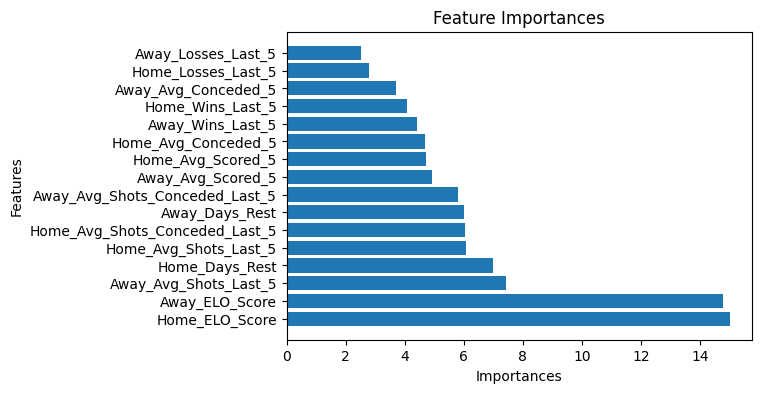

In [23]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
plt.barh(width=f_importances['Importances'],y=f_importances['Feature'])
plt.xlabel("Importances")
plt.ylabel("Features")
plt.title("Feature Importances")
plt.show()

In [24]:
y_pred=rf_classifier.predict_proba(X_test_rf)

In [25]:
def draw_filter(model):
  DRAW_THRESHOLD=0.25
  DRAW_PENALTY=0.5
  HOME_AWAY_BONUS=0.30

  filtered=model.copy()

  for i in range(len(filtered)):
    p_draw=filtered[i][1]

    if p_draw>=DRAW_THRESHOLD:
      filtered[i][1]=p_draw*DRAW_PENALTY
      filtered[i][0]+=p_draw*HOME_AWAY_BONUS
      filtered[i][2]+=p_draw*HOME_AWAY_BONUS
  return filtered

In [26]:
y_pred=draw_filter(y_pred)

In [27]:
for i in range(len(X_test)):
  print(f'===== Predictions for {X_test_copy[i][0]} vs {X_test_copy[i][1]} =====')
  print(X_test_copy[i][0]," Probability to win: {:.2f} %".format(y_pred[i,2]*100))
  print(X_test_copy[i][1]," Probability to win: {:.2f} %".format(y_pred[i,0]*100))
  print("Draw: {:.2f}% ".format(y_pred[i,1]*100))
  if y_test[i]==0:
    outcome=X_test_copy[i][1]
  elif y_test[i]==1:
    outcome="Draw"
  elif y_test[i]==2:
    outcome=X_test_copy[i][0]
  print(f"Outcome: {outcome}")
  print("\n"*2)

===== Predictions for Real Madrid vs Sociedad =====
Real Madrid  Probability to win: 66.40 %
Sociedad  Probability to win: 20.00 %
Draw: 13.60% 
Outcome: Real Madrid



===== Predictions for Oviedo vs Ath Bilbao =====
Oviedo  Probability to win: 27.84 %
Ath Bilbao  Probability to win: 57.44 %
Draw: 18.40% 
Outcome: Ath Bilbao



===== Predictions for Vallecano vs Ath Madrid =====
Vallecano  Probability to win: 35.60 %
Ath Madrid  Probability to win: 43.60 %
Draw: 26.00% 
Outcome: Vallecano



===== Predictions for Levante vs Valencia =====
Levante  Probability to win: 47.36 %
Valencia  Probability to win: 38.56 %
Draw: 17.60% 
Outcome: Valencia



===== Predictions for Mallorca vs Betis =====
Mallorca  Probability to win: 44.32 %
Betis  Probability to win: 40.32 %
Draw: 19.20% 
Outcome: Betis



===== Predictions for Girona vs Barcelona =====
Girona  Probability to win: 21.36 %
Barcelona  Probability to win: 62.96 %
Draw: 19.60% 
Outcome: Girona



===== Predictions for Levante vs Vill

In [28]:
from xgboost import XGBClassifier
classifier=XGBClassifier(learning_rate=0.01)

In [29]:
from sklearn.utils.class_weight import compute_sample_weight
class_weights={0:1.5,1:0.6,2:1.5}
sample_weights=compute_sample_weight(class_weight=class_weights,y=y_train)

In [30]:
xg_parameters={
    'n_estimators':[300,400,500,700],
    'colsample_bytree':[0.8,1]
}
grid_search_xg=GridSearchCV(estimator=classifier,
                            param_grid=xg_parameters,
                            n_jobs=-1,
                            verbose=2,
                            scoring='accuracy')
grid_search_xg.fit(X_train,y_train)
print("Best accuracy for Calibrated XGB : {:.2f}%".format(grid_search_xg.best_score_*100))
print("Best parameters for Calibrated XGB Classifier: ",grid_search_xg.best_params_)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best accuracy for Calibrated XGB : 46.49%
Best parameters for Calibrated XGB Classifier:  {'colsample_bytree': 0.8, 'n_estimators': 300}


In [31]:
classifier=XGBClassifier(colsample_bytree=0.8,
                         learning_rate=0.01,
                         n_estimators=300,
                         )
classifier.fit(X=X_train_rf,y=y_train,sample_weight=sample_weights)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method

In [32]:
from sklearn.calibration import CalibratedClassifierCV
calibrated_XG=CalibratedClassifierCV(estimator=classifier,method='sigmoid')
calibrated_XG.fit(X_train_rf,y_train)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2","XGBClassifier...ree=None, ...)"
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'sigmoid'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary ` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: float | typing.List[float] | NoneThe initial pre

In [33]:
y_pred_XG=calibrated_XG.predict_proba(X_test_rf)

In [34]:
y_pred_XG=draw_filter(y_pred_XG)

In [35]:
for i in range(len(X_test)):
  print(f'===== Predictions for {X_test_copy[i][0]} vs {X_test_copy[i][1]} =====')
  print(X_test_copy[i][0]," Probability to win: {:.2f} %".format(y_pred_XG[i,2]*100))
  print(X_test_copy[i][1]," Probability to win: {:.2f} %".format(y_pred_XG[i,0]*100))
  print("Draw: {:.2f}% ".format(y_pred_XG[i,1]*100))
  if y_test[i]==0:
    outcome=X_test_copy[i][1]
  elif y_test[i]==1:
    outcome="Draw"
  elif y_test[i]==2:
    outcome=X_test_copy[i][0]
  print(f"Outcome: {outcome}")
  print("\n"*2)

===== Predictions for Real Madrid vs Sociedad =====
Real Madrid  Probability to win: 50.84 %
Sociedad  Probability to win: 29.62 %
Draw: 19.54% 
Outcome: Real Madrid



===== Predictions for Oviedo vs Ath Bilbao =====
Oviedo  Probability to win: 39.49 %
Ath Bilbao  Probability to win: 49.35 %
Draw: 13.95% 
Outcome: Ath Bilbao



===== Predictions for Vallecano vs Ath Madrid =====
Vallecano  Probability to win: 42.80 %
Ath Madrid  Probability to win: 40.59 %
Draw: 20.76% 
Outcome: Vallecano



===== Predictions for Levante vs Valencia =====
Levante  Probability to win: 45.17 %
Valencia  Probability to win: 42.35 %
Draw: 15.60% 
Outcome: Valencia



===== Predictions for Mallorca vs Betis =====
Mallorca  Probability to win: 42.65 %
Betis  Probability to win: 44.73 %
Draw: 15.77% 
Outcome: Betis



===== Predictions for Girona vs Barcelona =====
Girona  Probability to win: 29.56 %
Barcelona  Probability to win: 47.43 %
Draw: 23.01% 
Outcome: Girona



===== Predictions for Levante vs Vill

In [36]:
import numpy as np
final_rf_pred=np.argmax(y_pred,axis=1)
final_XG_pred=np.argmax(y_pred_XG,axis=1)

In [37]:

from sklearn.metrics import confusion_matrix, classification_report
print("Confusion Matrix of the RandomForest Classifier Model")
print(confusion_matrix(y_test,final_rf_pred))
print(classification_report(y_test,final_rf_pred, zero_division=0))

print()
print("Confusion Matrix of the XGBoost Classifier Model")
print(confusion_matrix(y_test,final_XG_pred))
print(classification_report(y_test,final_XG_pred, zero_division=0))

Confusion Matrix of the RandomForest Classifier Model
[[ 2  0 12]
 [ 1  0 12]
 [ 9  0 22]]
              precision    recall  f1-score   support

           0       0.17      0.14      0.15        14
           1       0.00      0.00      0.00        13
           2       0.48      0.71      0.57        31

    accuracy                           0.41        58
   macro avg       0.21      0.28      0.24        58
weighted avg       0.30      0.41      0.34        58


Confusion Matrix of the XGBoost Classifier Model
[[ 3  0 11]
 [ 1  0 12]
 [ 5  0 26]]
              precision    recall  f1-score   support

           0       0.33      0.21      0.26        14
           1       0.00      0.00      0.00        13
           2       0.53      0.84      0.65        31

    accuracy                           0.50        58
   macro avg       0.29      0.35      0.30        58
weighted avg       0.36      0.50      0.41        58



In [38]:

from sklearn.model_selection import cross_val_score,StratifiedKFold
skf=StratifiedKFold(n_splits=5)
accuracy_rf=cross_val_score(estimator=rf_classifier,X=X_train,y=y_train,cv=skf)
print("Cross Validation Scores of RF Model: {}".format(accuracy_rf))
print("Mean Accuracy of Random Forest Classifier: {:.2f} %".format(accuracy_rf.mean()*100))
print("Standard Deviation of RF Classifier: {:.2f} %".format(accuracy_rf.std()*100))
print()
accuracy_XG=cross_val_score(estimator=classifier,X=X_train,y=y_train,cv=skf)
print("Cross Validation Scores of XGBoost Model: {}".format(accuracy_XG))
print("Accuracy of XGBoost Classifier: {:.2f} %".format(accuracy_XG.mean()*100))
print("Standard Deviation of XGBoost Classifier: {:.2f} %".format(accuracy_XG.std()*100))

Cross Validation Scores of RF Model: [0.55319149 0.44680851 0.5        0.41304348 0.39130435]
Mean Accuracy of Random Forest Classifier: 46.09 %
Standard Deviation of RF Classifier: 5.90 %

Cross Validation Scores of XGBoost Model: [0.59574468 0.46808511 0.52173913 0.39130435 0.34782609]
Accuracy of XGBoost Classifier: 46.49 %
Standard Deviation of XGBoost Classifier: 8.89 %


In [39]:

from sklearn.model_selection import TimeSeriesSplit
tscv = TimeSeriesSplit()
accuracy_rf=cross_val_score(estimator=rf_classifier,X=X_train,y=y_train,cv=tscv)
print("Cross Validation Scores of RF Model: {}".format(accuracy_rf))
print("Mean Accuracy of Random Forest Classifier: {:.2f} %".format(accuracy_rf.mean()*100))
print("Standard Deviation of RF Classifier: {:.2f} %".format(accuracy_rf.std()*100))
print()
accuracy_XG=cross_val_score(estimator=classifier,X=X_train,y=y_train,cv=tscv)
print("Cross Validation Scores of XGBoost Model: {}".format(accuracy_XG))
print("Accuracy of XGBoost Classifier: {:.2f} %".format(accuracy_XG.mean()*100))
print("Standard Deviation of XGBoost Classifier: {:.2f} %".format(accuracy_XG.std()*100))

Cross Validation Scores of RF Model: [0.60526316 0.52631579 0.44736842 0.44736842 0.39473684]
Mean Accuracy of Random Forest Classifier: 48.42 %
Standard Deviation of RF Classifier: 7.37 %

Cross Validation Scores of XGBoost Model: [0.52631579 0.44736842 0.34210526 0.36842105 0.36842105]
Accuracy of XGBoost Classifier: 41.05 %
Standard Deviation of XGBoost Classifier: 6.78 %


In [40]:
# import joblib
# joblib.dump(calibrated_XG,'XGBClassifier_LaLiga.pkl')
# joblib.dump(rf_classifier,'RFClassifier_LaLiga.pkl')

In [44]:
all_features=dataset_laliga.drop(columns=['FTR','HomeTeam','AwayTeam']).columns
selected_feature_indices = selector.get_support()
final_features = all_features[selected_feature_indices]

print(list(final_features))

# joblib.dump(list(final_features), 'model_features.pkl')

['Home_Days_Rest', 'Away_Days_Rest', 'Home_Avg_Scored_5', 'Home_Avg_Conceded_5', 'Home_Avg_Shots_Last_5', 'Home_Avg_Shots_Conceded_Last_5', 'Away_Avg_Scored_5', 'Away_Avg_Shots_Last_5', 'Away_Avg_Shots_Conceded_Last_5', 'Home_ELO_Score', 'Away_ELO_Score']


In [43]:
all_teams=dataset_laliga['HomeTeam'].unique()
current_team_data={}
import joblib
for team in all_teams:
    team_data=team_stats[team_stats['Team']==team].iloc[-1]

    current_team_data[team]={
       'Team':team,
       'ELO Rating':teams_elo.get(team),
       'Avg_Shots_Last_5':team_data['Avg_Shots_Last_5'],
       'Avg_Shots_Conceded_Last_5': team_data['Avg_Shots_Conceded_Last_5'],
       'Avg_Scored_Last_5':team_data['Avg_Scored_Last_5'],
       'Avg_Conceded_Last_5':team_data['Avg_Conceded_Last_5']
    }
joblib.dump(current_team_data,'Clubs Data_LaLiga.pkl')

['Clubs Data_LaLiga.pkl']